## Case Study: Adaptive Domain N-gram Benchmark
### Zhdanov Andrei AI-01

In [ ]:
# function for cleaning domain dataset
import re
from collections import Counter

def clean_text(text):
    text = text.lower()
    text = re.sub(r"'s\b", "", text)      
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def save_clean_corpus(lines, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        for line in lines:
            clean = clean_text(line)
            if clean:
                f.write(clean + "\n")

def load_corpus(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    return lines


def tokenize(lines):
    tokens = []
    for line in lines:
        clean = clean_text(line)
        tokens.extend(clean.split())
    return tokens

def corpus_stats(tokens):
    total_tokens = len(tokens)
    vocab = set(tokens)
    vocab_size = len(vocab)

    counter = Counter(tokens)

    print(" Domain Corpus Stats:")
    print(f"Total tokens: {total_tokens}")
    print(f"Vocabulary size: {vocab_size}")
    print(f"Top 20 words: {counter.most_common(20)}")

    return counter

### Collect domain dataset using steam API
- parse reviews from dota 2, cs go, factorio

In [4]:
import requests
import time

def get_reviews(appid, max_reviews=5000):
    url = f"https://store.steampowered.com/appreviews/{appid}"
    reviews = []
    cursor = "*"
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    while len(reviews) < max_reviews:
        params = {
            "json": 1,
            "language": "english",
            "filter": "recent",
            "num_per_page": 100,
            "cursor": cursor
        }

        try:
            r = requests.get(url, params=params, headers=headers, timeout=10)
            data = r.json()
        except Exception as e:
            print("Error:", e)
            time.sleep(5)
            continue

        for review in data["reviews"]:
            text = review["review"]
            reviews.append(text)

        cursor = data["cursor"]

        if not data["reviews"]:
            break

        time.sleep(1)

    return reviews[:max_reviews]

dota = get_reviews(570, 3000)
csgo = get_reviews(730, 3000)
factorio = get_reviews(427520, 3000)

all_reviews = dota + csgo + factorio

with open("gaming_corpus_raw.txt", "w", encoding="utf-8") as f:
    for r in all_reviews:
        f.write(r.replace("\n", " ") + "\n")

print("Done:", len(all_reviews))

Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read timed out. (read timeout=10)
Error: HTTPSConnectionPool(host='store.steampowered.com', port=443): Read

### Download Baseline dataset
- use brown dataset for baseline
- limit tokens to 140000, becouse domain dataset have around 140000 tokens

In [9]:
import nltk
nltk.download('brown')
from nltk.corpus import brown

def load_brown_sentences(limit_tokens=140000):
    sents = []
    total = 0

    for sent in brown.sents():
        clean_sent = [w.lower() for w in sent if w.isalpha()]
        if len(clean_sent) >= 3:
            sents.append(clean_sent)
            total += len(clean_sent)
        if total >= limit_tokens:
            break

    return sents

base_sents = load_brown_sentences(limit_tokens=140000)

print("Number of base sentences:", len(base_sents))
print("Example:", base_sents[0][:20])


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\k4ty2\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


Number of base sentences: 7457
Example: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took']


### Prepare domain dataset to pass to N-grams
- Also look on statistic

In [10]:
def load_sentences_from_clean_file(path):
    sents = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            tokens = line.strip().split()
            if len(tokens) >= 3:
                sents.append(tokens)
    return sents


file_path = "gaming_corpus_raw.txt"

lines = load_corpus(file_path)
tokens = tokenize(lines)
counter = corpus_stats(tokens)
save_clean_corpus(lines, "gaming_corpus_clean.txt")

domain_sents = load_sentences_from_clean_file("gaming_corpus_clean.txt")

print("Number of domain sentences:", len(domain_sents))
print("Example:", domain_sents[0][:20])

 Domain Corpus Stats:
Total tokens: 141147
Vocabulary size: 10978
Top 20 words: [('the', 6006), ('game', 4734), ('i', 3471), ('and', 3254), ('to', 3110), ('you', 2887), ('a', 2815), ('it', 2557), ('is', 2339), ('this', 2219), ('of', 2213), ('factory', 1453), ('must', 1394), ('in', 1315), ('grow', 1268), ('for', 1255), ('good', 1252), ('that', 1042), ('but', 972), ('my', 906)]
Number of domain sentences: 6310
Example: ['dota', 'is', 'life']


### Draw word cloud for domain and baseline dataset

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\k4ty2\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


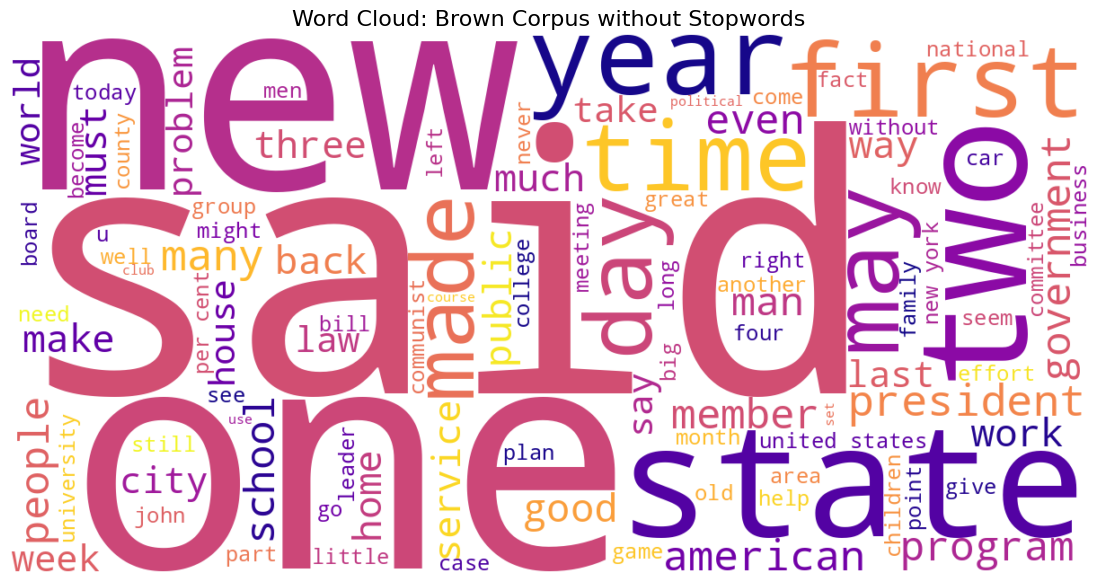

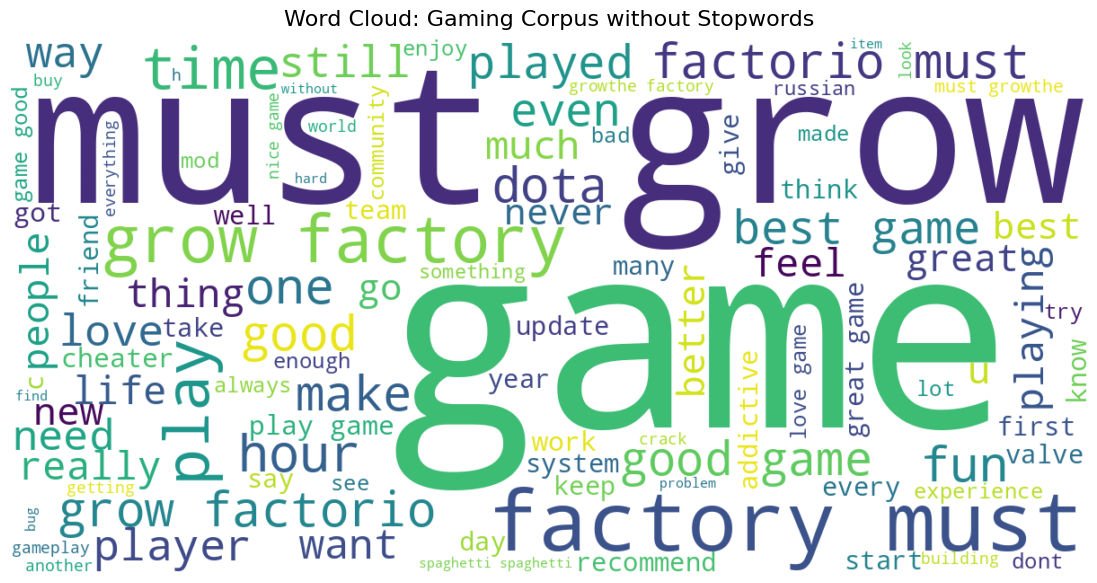

In [18]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def remove_stopwords_from_sents(sentences, stop_words):
    cleaned_sents = []
    for sent in sentences:
        filtered = [w for w in sent if w not in stop_words]
        if filtered:
            cleaned_sents.append(filtered)
    return cleaned_sents

def flatten_sentences_to_text(sentences):
    return " ".join(word for sent in sentences for word in sent)

base_sents_nostop = remove_stopwords_from_sents(base_sents, stop_words)
domain_sents_nostop = remove_stopwords_from_sents(domain_sents, stop_words)

base_text_nostop = flatten_sentences_to_text(base_sents_nostop)
domain_text_nostop = flatten_sentences_to_text(domain_sents_nostop)

wc_base = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="plasma",
    max_words=100
).generate(base_text_nostop)

wc_domain = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(domain_text_nostop)

plt.figure(figsize=(14, 7))
plt.imshow(wc_base, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Brown Corpus without Stopwords", fontsize=16)
plt.show()

plt.figure(figsize=(14, 7))
plt.imshow(wc_domain, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Gaming Corpus without Stopwords", fontsize=16)
plt.show()


### Split Domain dataset to test and train sets

In [11]:
import random
random.seed(42)

def split_domain_data(sentences, train_ratio=0.8):
    sentences = sentences.copy()
    random.shuffle(sentences)

    split_idx = int(len(sentences) * train_ratio)
    adapt_pool = sentences[:split_idx]
    test_sents = sentences[split_idx:]

    return adapt_pool, test_sents

domain_pool, domain_test = split_domain_data(domain_sents, train_ratio=0.8)

print("Domain adapt pool:", len(domain_pool))
print("Domain test:", len(domain_test))


Domain adapt pool: 5048
Domain test: 1262


### Functions for metrics:
- **Perplexity** — measures how well the model predicts in-domain text
- **Coverage** — proportion of test tokens seen in the training vocabulary
- **OOV rate** — proportion of out-of-vocabulary test tokens
- **Rare-word statistics** — proportions of unseen, rare, and frequent words in the test set

In [14]:
from nltk.util import everygrams
from nltk.lm.preprocessing import pad_both_ends


def compute_perplexity(model, test_sents, n):
    test_ngrams = []
    for sent in test_sents:
        padded = list(pad_both_ends(sent, n=n))
        sent_ngrams = list(everygrams(padded, max_len=n))
        test_ngrams.extend(sent_ngrams)
    return model.perplexity(test_ngrams)

def get_vocab_from_sentences(sentences):
    vocab = set()
    for sent in sentences:
        vocab.update(sent)
    return vocab

def word_coverage(train_sents, test_sents):
    train_vocab = get_vocab_from_sentences(train_sents)
    test_tokens = [w for sent in test_sents for w in sent]

    covered = sum(1 for w in test_tokens if w in train_vocab)
    total = len(test_tokens)

    coverage = covered / total if total > 0 else 0
    oov_rate = 1 - coverage

    return coverage, oov_rate

def rare_word_stats(train_sents, test_sents, rare_thresh=5):
    train_counts = Counter(w for sent in train_sents for w in sent)
    test_tokens = [w for sent in test_sents for w in sent]

    unseen = sum(1 for w in test_tokens if w not in train_counts)
    rare = sum(1 for w in test_tokens if w in train_counts and train_counts[w] <= rare_thresh)
    frequent = sum(1 for w in test_tokens if w in train_counts and train_counts[w] > rare_thresh)

    total = len(test_tokens)

    return {
        "unseen_rate": unseen / total if total else 0,
        "rare_rate": rare / total if total else 0,
        "frequent_rate": frequent / total if total else 0
    }



### Initialization of ngram models and trial training on the base dataset

In [ ]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace

def train_lm(train_sents, n=3):
    train_data, vocab = padded_everygram_pipeline(n, train_sents)
    model = Laplace(n)
    model.fit(train_data, vocab)
    return model

lm3_base = train_lm(base_sents, n=3)
lm5_base = train_lm(base_sents, n=5)

rare_base = rare_word_stats(base_sents, domain_test)
coverage_base, oov_base = word_coverage(base_sents, domain_test)

print("Baseline coverage:", coverage_base)
print("Baseline OOV rate:", oov_base)
print(rare_base)

ppl3_base = compute_perplexity(lm3_base, domain_test, 3)
ppl5_base = compute_perplexity(lm5_base, domain_test, 5)

print("Baseline 3-gram perplexity:", ppl3_base)
print("Baseline 5-gram perplexity:", ppl5_base)

Baseline coverage: 0.8673279140875532
Baseline OOV rate: 0.13267208591244684
{'unseen_rate': 0.13267208591244686, 'rare_rate': 0.1134685658885823, 'frequent_rate': 0.7538593481989708}
Baseline 3-gram perplexity: 3705.3745786987233
Baseline 5-gram perplexity: 2832.480024147269


### Setup incremental Domain Adaptation Experiment

The experiment starts with a baseline model trained only on the general-domain Brown corpus. Then, the model is incrementally adapted by adding 10%, 25%, 50%, and 100% of the gaming-domain training pool.

At each adaptation stage, the model is evaluated on the same held-out gaming test set

The same procedure is applied to both **3-gram** and **5-gram** language models in order to compare how shorter and longer contexts behave under domain adaptation.


In [16]:
def take_portion(data, portion):
    k = int(len(data) * portion)
    return data[:k]


def run_incremental_experiment(base_sents, domain_pool, domain_test, n=3):
    portions = [0.0, 0.1, 0.25, 0.5, 1.0]
    results = []

    for p in portions:
        adapt_part = take_portion(domain_pool, p)
        train_sents = base_sents + adapt_part

        model = train_lm(train_sents, n=n)
        ppl = compute_perplexity(model, domain_test, n)
        coverage, oov_rate = word_coverage(train_sents, domain_test)
        rare_stats = rare_word_stats(train_sents, domain_test)

        row = {
            "portion": p,
            "n": n,
            "perplexity": ppl,
            "coverage": coverage,
            "oov_rate": oov_rate,
            "unseen_rate": rare_stats["unseen_rate"],
            "rare_rate": rare_stats["rare_rate"],
            "frequent_rate": rare_stats["frequent_rate"]
        }
        results.append(row)

    return results


results_3 = run_incremental_experiment(base_sents, domain_pool, domain_test, n=3)
results_5 = run_incremental_experiment(base_sents, domain_pool, domain_test, n=5)

print("3-gram results:")
for r in results_3:
    print(r)

print("\n5-gram results:")
for r in results_5:
    print(r)


3-gram results:
{'portion': 0.0, 'n': 3, 'perplexity': 3705.3745786987233, 'coverage': 0.8673279140875532, 'oov_rate': 0.13267208591244684, 'unseen_rate': 0.13267208591244686, 'rare_rate': 0.1134685658885823, 'frequent_rate': 0.7538593481989708}
{'portion': 0.1, 'n': 3, 'perplexity': 2894.0184198724783, 'coverage': 0.9316130956820047, 'oov_rate': 0.06838690431799532, 'unseen_rate': 0.06838690431799538, 'rare_rate': 0.10921768961145499, 'frequent_rate': 0.8223954060705496}
{'portion': 0.25, 'n': 3, 'perplexity': 2570.025255040737, 'coverage': 0.9436945335222612, 'oov_rate': 0.05630546647773882, 'unseen_rate': 0.05630546647773883, 'rare_rate': 0.0928480871056753, 'frequent_rate': 0.8508464464165859}
{'portion': 0.5, 'n': 3, 'perplexity': 2277.865416125939, 'coverage': 0.9515250950853904, 'oov_rate': 0.048474904914609596, 'unseen_rate': 0.04847490491460959, 'rare_rate': 0.0787157879036468, 'frequent_rate': 0.8728093071817437}
{'portion': 1.0, 'n': 3, 'perplexity': 2049.67548391885, 'cover

### Draw graphics

   portion  n   perplexity  coverage  oov_rate  unseen_rate  rare_rate  \
0     0.00  3  3705.374579  0.867328  0.132672     0.132672   0.113469   
1     0.10  3  2894.018420  0.931613  0.068387     0.068387   0.109218   
2     0.25  3  2570.025255  0.943695  0.056305     0.056305   0.092848   
3     0.50  3  2277.865416  0.951525  0.048475     0.048475   0.078716   
4     1.00  3  2049.675484  0.960996  0.039004     0.039004   0.063278   
5     0.00  5  2832.480024  0.867328  0.132672     0.132672   0.113469   
6     0.10  5  2415.014379  0.931613  0.068387     0.068387   0.109218   
7     0.25  5  2255.358279  0.943695  0.056305     0.056305   0.092848   
8     0.50  5  2068.172540  0.951525  0.048475     0.048475   0.078716   
9     1.00  5  1966.756955  0.960996  0.039004     0.039004   0.063278   

   frequent_rate  
0       0.753859  
1       0.822395  
2       0.850846  
3       0.872809  
4       0.897718  
5       0.753859  
6       0.822395  
7       0.850846  
8       0.8728

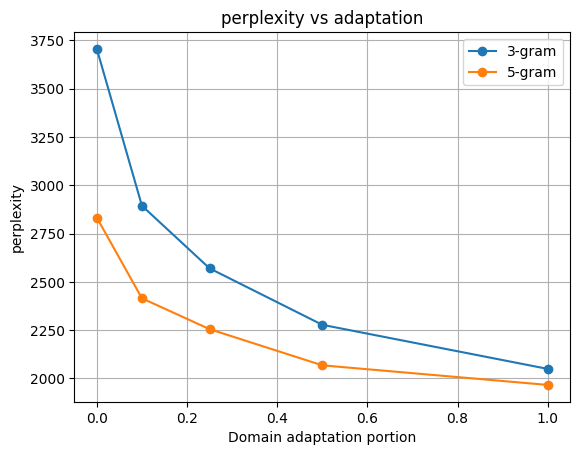

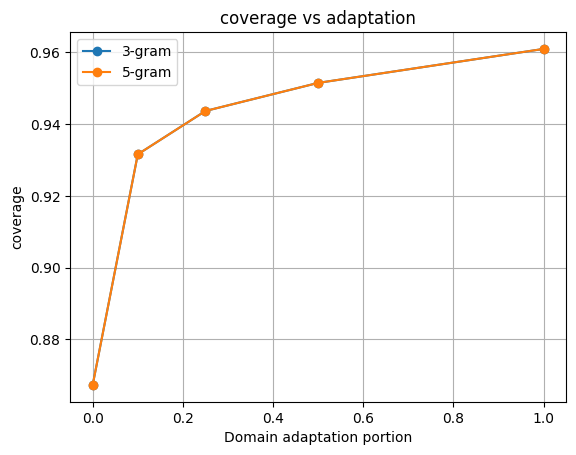

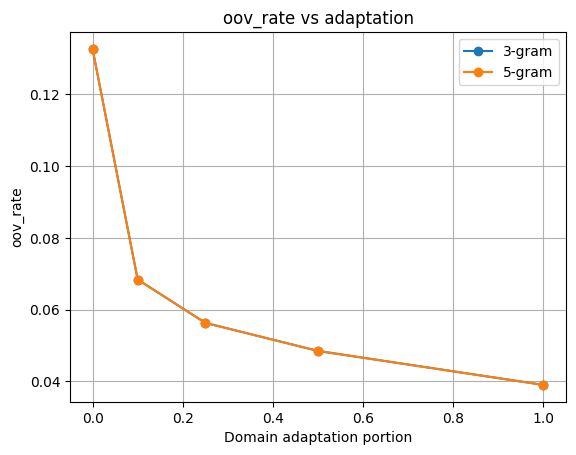

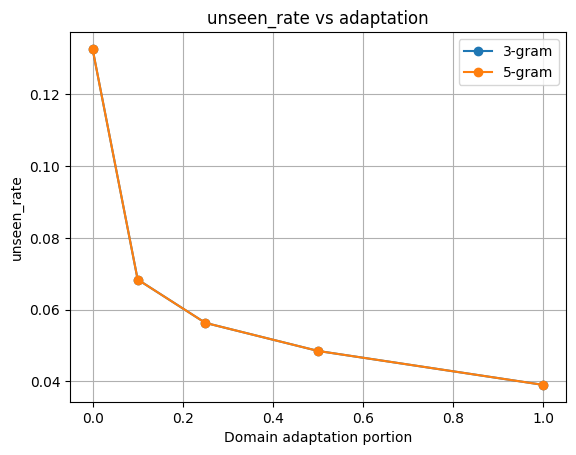

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


df3 = pd.DataFrame(results_3)
df5 = pd.DataFrame(results_5)
df = pd.concat([df3, df5], ignore_index=True)

print(df)

def plot_metric(df, metric):
    for n in sorted(df["n"].unique()):
        sub = df[df["n"] == n]
        plt.plot(sub["portion"], sub[metric], marker="o", label=f"{n}-gram")

    plt.xlabel("Domain adaptation portion")
    plt.ylabel(metric)
    plt.title(f"{metric} vs adaptation")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric(df, "perplexity")
plot_metric(df, "coverage")
plot_metric(df, "oov_rate")
plot_metric(df, "unseen_rate")
